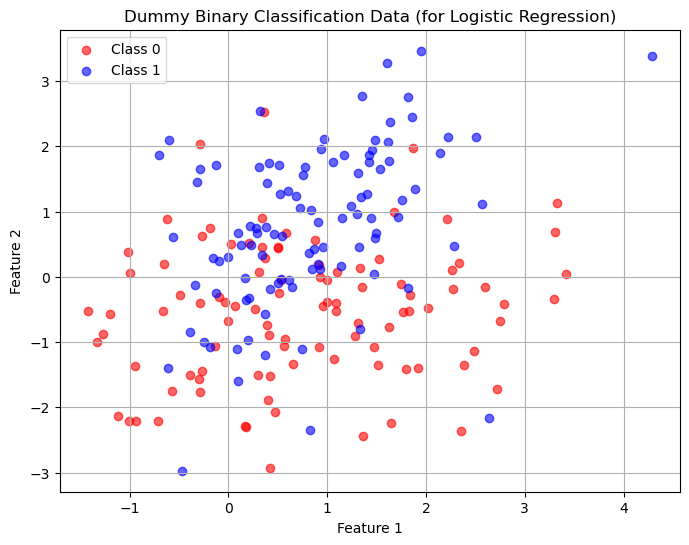

Features shape: (200, 2)
Target shape: (200,)


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split


# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [84]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [85]:
#data splitting
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.4, random_state=42, stratify=y
)

In [86]:
X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)
X_test=pd.DataFrame(X_test)
y_test= pd.DataFrame(y_test)

In [87]:
def information_gain(X_train, Y_train, f_name):
    thresholds = np.unique(X_train.iloc[:,f_name])
    # threshold = np.unique(x)

    temp_best_x_left=None
    temp_best_y_left=None
    temp_best_x_right=None
    temp_best_y_right=None
    

    # y = np.unique(x)
    total = len(Y_train)
    left_u= np.unique(Y_train)
    n_probs = []
    for n_class in left_u:
        p1 = np.sum(Y_train == n_class)/total
        n_probs.append(p1) 
    n_probs = np.array(n_probs)
    H_root = np.sum(-n_probs*np.log2(n_probs))

    H_dn = 0 # initial entropy
    best_IG = -1
    
    
    for th in thresholds:

        left_b_x = X_train[X_train[f_name] <= th]
        left_b_y = Y_train[X_train[f_name]<=th]

        right_b_x = X_train[X_train[f_name]>th]
        right_b_y = Y_train[X_train[f_name]>th]
        
        left_m = len(left_b_x)
        right_m = len(right_b_x)
        n_probs_left = []
        n_probs_right = []
        
    
        left_v = np.unique(left_b_y)
        right_v = np.unique(right_b_y)

        for n_class in left_v:
            p1 = np.sum(left_b_y == n_class)/left_m
            n_probs_left.append(p1)
        for n_class in right_v:
            p1 = np.sum(right_b_y == n_class)/right_m
            n_probs_right.append(p1)
    
        n_probs_left = np.array(n_probs_left)
        n_probs_right = np.array(n_probs_right)

        l_entropy = (left_m/total) * np.sum(-n_probs_left*np.log2(n_probs_left))
        r_entropy = (right_m/total) * np.sum(-n_probs_right*np.log2(n_probs_right))
    
        H_dn = l_entropy + r_entropy
        IG = H_root - H_dn
        if IG > best_IG:
            best_IG = IG
            best_threshold = th 
            temp_best_x_right = right_b_x
            temp_best_y_right = right_b_y
            temp_best_x_left = left_b_x
            temp_best_y_left = left_b_y
    
    return best_IG, [temp_best_x_left, temp_best_x_right], [temp_best_y_left,temp_best_y_right], best_threshold 

In [88]:
information_gain(X_train,y_train, 0)

C:\Users\ADMIN\anaconda3_new\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


(np.float64(0.09101787862171862),
 [            0         1
  7   -0.711394 -2.208189
  8   -1.119512 -2.125239
  27  -1.006209 -2.211680
  28  -0.652843  0.192546
  38  -0.935702 -2.212015
  42  -0.664201 -0.521315
  59  -1.331681 -0.996678
  66  -0.574686 -1.751525
  67  -1.421998 -0.528861
  117 -0.997938  0.061337,
              0         1
  0    0.027912  0.501628
  1    0.422201 -2.921909
  2    2.337627  0.210944
  3    0.123212  0.481159
  4    0.173727 -0.356532
  ..        ...       ...
  114  0.308913  0.080403
  115  2.220996  2.140428
  116  0.335900  0.456330
  118  0.569275 -0.951342
  119  1.643461 -2.241687
  
  [110 rows x 2 columns]],
 [     0
  7    0
  8    0
  27   0
  28   0
  38   0
  42   0
  59   0
  66   0
  67   0
  117  0,
       0
  0    0
  1    0
  2    0
  3    1
  4    1
  ..  ..
  114  0
  115  1
  116  0
  118  0
  119  0
  
  [110 rows x 1 columns]],
 np.float64(-0.5746856027104121))

In [102]:
number_classes = len(y_train[0].unique())
depth = 4

best_x_csvs_branchs = [X_train]
best_y_csvs_branchs = [y_train]


tree = {}##################3
root_node = []
for d in range(depth):
    next_x_branches = []
    next_y_branches = []
    
    for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_csvs_branchs, best_y_csvs_branchs):
        IG_value = -np.inf
        best_feature = None
        temp_best_x_csvs_branch = None
        temp_best_y_csvs_branch = None
        
        y_pred = None
        best_th = None
        
        for f_name in X_train.columns:
            IG, x_csvs_branch, y_csvs_branch, threshold = information_gain(best_x_csvs_branch, best_y_csvs_branch, f_name)
            
            if IG > IG_value:
                
                IG_value = IG
                if IG_value>0:
                    temp_best_x_csvs_branch = x_csvs_branch
                    temp_best_y_csvs_branch = y_csvs_branch
                    
                    best_feature = f_name
                    best_th = threshold
                         
                else:
                    # y_pred = None
                    y_pred= y_csvs_branch[0][0].unique()
                    # best_feature = le.inverse_transfor (np.unique(y))[0]
        
        print(best_feature, IG_value)

        node_id = id(best_x_csvs_branch)##################
        root_node.append(node_id)
        tree[node_id] = {             ###################3
            "feature": best_feature,
            "ig": IG_value,
            "children":[],
            "th":best_th,
            "pred":y_pred
        } #####################################
        
        if temp_best_x_csvs_branch is not None:
            next_x_branches.extend(temp_best_x_csvs_branch)
            next_y_branches.extend(temp_best_y_csvs_branch)

            for child_x in temp_best_x_csvs_branch: ###########
               
                tree[node_id]["children"].append(id(child_x))
                
    best_x_csvs_branchs = next_x_branches
    best_y_csvs_branchs = next_y_branches
    
    if d == depth-1:
        for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_csvs_branchs, best_y_csvs_branchs):
            y_pred = best_y_csvs_branch[0].value_counts().idxmax()
             # y_pred= best_y_csvs_branch[0].value_counts().idxmax()
            node_id = id(best_x_csvs_branch)
            tree[node_id]={
                 
                "feature": None,
                "ig": None,
                "children": [],
                "pred":y_pred
            }#####################
        
    

C:\Users\ADMIN\anaconda3_new\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


1 0.16520766441438106
0 0.09099570292543468
1 0.17523196051238366
0 0.11268364362703709
None 0.0
None 0.0
1 0.44643934467101554
None 0.0
1 0.046376469413387134
None 0.0
0 0.2935644431995964


In [103]:
tree

{2122595245360: {'feature': 1,
  'ig': np.float64(0.16520766441438106),
  'children': [2122599264032, 2122599261568],
  'th': np.float64(0.9068843220944874),
  'pred': None},
 2122599264032: {'feature': 0,
  'ig': np.float64(0.09099570292543468),
  'children': [2122546425744, 2122599253840],
  'th': np.float64(1.8143881315781485),
  'pred': None},
 2122599261568: {'feature': 1,
  'ig': np.float64(0.17523196051238366),
  'children': [2122599262464, 2122599253280],
  'th': np.float64(1.9608450630045966),
  'pred': None},
 2122546425744: {'feature': 0,
  'ig': np.float64(0.11268364362703709),
  'children': [2122599267728, 2122599257536],
  'th': np.float64(-0.5746856027104121),
  'pred': None},
 2122599253840: {'feature': None,
  'ig': np.float64(0.0),
  'children': [],
  'th': None,
  'pred': array([0])},
 2122599262464: {'feature': None,
  'ig': np.float64(0.0),
  'children': [],
  'th': None,
  'pred': array([1])},
 2122599253280: {'feature': 1,
  'ig': np.float64(0.44643934467101554),

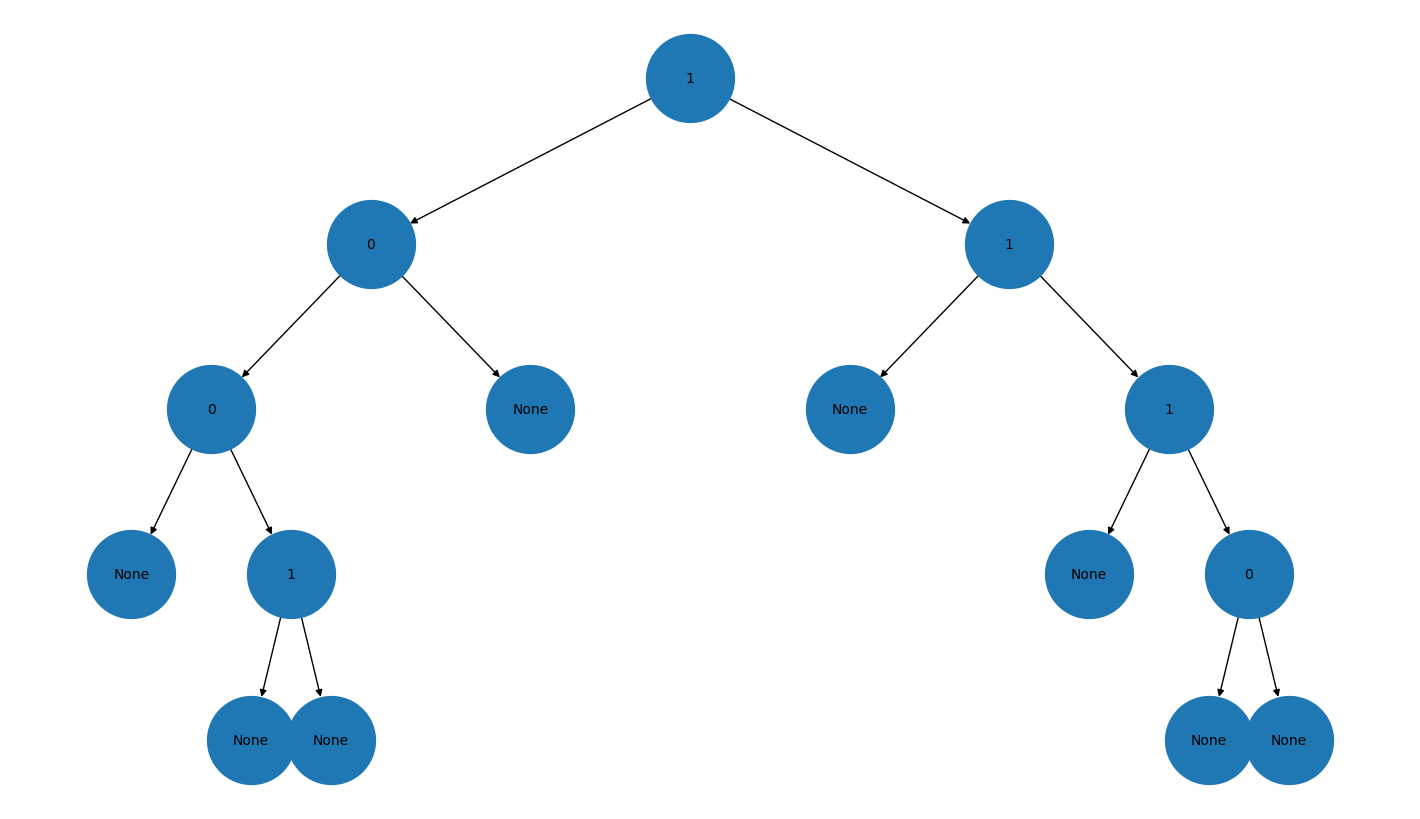

In [91]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for node_id, info in tree.items():
    G.add_node(node_id, label=info["feature"])

for node_id, info in tree.items():
    for child in info["children"]:
        G.add_edge(node_id, child)

# Root node = first key in dictionary
root = list(tree.keys())[0]

def hierarchy_pos(G, root, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
    pos = {root: (xcenter, vert_loc)}
    children = list(G.successors(root))

    if len(children):
        dx = width / len(children)
        nextx = xcenter - width/2 - dx/2

        for child in children:
            nextx += dx
            pos.update(
                hierarchy_pos(
                    G,
                    child,
                    width=dx,
                    vert_gap=vert_gap,
                    vert_loc=vert_loc-vert_gap,
                    xcenter=nextx
                )
            )
    return pos

pos = hierarchy_pos(G, root)

labels = {n: tree[n]["feature"] for n in tree}

plt.figure(figsize=(14,8))
nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=4000,
    font_size=10
)

plt.show()

In [108]:
y_pred = []
for i in range(len(X_test)):
    nid = root_node[0]
    while 1:
        search = tree[nid]["feature"]
        if search is not None :
            feature_name = tree[nid]["feature"]
            value=X_test[feature_name][i]

            if value<=tree[nid]["th"]:
                children_id=0
            else:
                children_id = 1
            nid = tree[nid]["children"][children_id]     
        else:
            y_pred.append(tree[nid]["pred"])
            break
y_true_labels = y_test

y_pred_flat = np.array([
    x.item() if isinstance(x, np.ndarray) else x
    for x in y_pred
])

accuracy = np.mean(y_true_labels.values.reshape(-1) == y_pred_flat) * 100
print(accuracy)

80.0


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13880\3431378117.py:70: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] = predict_point(


Unique classes: [0. 1.]


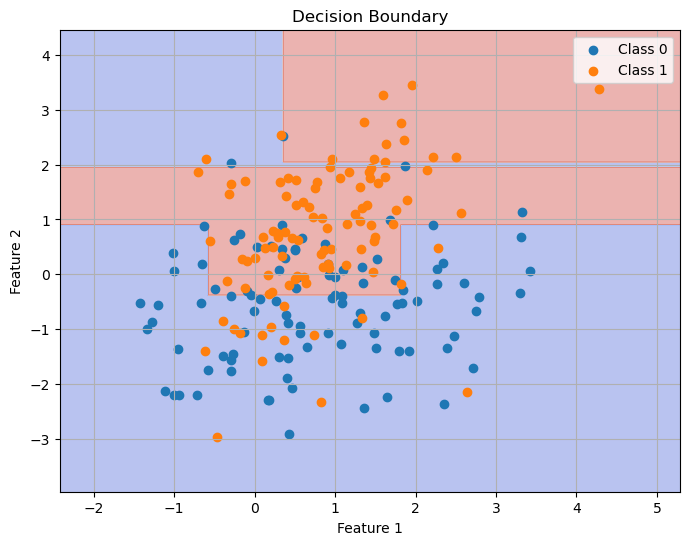

In [109]:
def predict_point(point, tree, root_node):

    nid = root_node[0]

    while True:

        # Node exists?
        if nid not in tree:
            return 0

        node = tree[nid]

        # Safe access
        feature = node.get("feature", None)
        children = node.get("children", [])
        pred = node.get("pred", 0)

        # Leaf node
        if feature is None or len(children) == 0:
            return pred

        th = node.get("th", None)

        if th is None:
            return pred

        # Feature value
        value = point[feature]

        # Left / Right branch
        if value <= th:
            idx = 0
        else:
            idx = 1

        # Child exists?
        if idx >= len(children):
            return pred

        next_nid = children[idx]

        # Next node exists?
        if next_nid not in tree:
            return pred

        nid = next_nid

# ================= CREATE GRID =================

x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

# ================= PREDICT GRID =================

Z = np.zeros(xx.shape)

for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):

        point = {
            0: xx[i, j],
            1: yy[i, j]
        }

        Z[i, j] = predict_point(
            point,
            tree,
            root_node
        )

print("Unique classes:", np.unique(Z))

# ================= PLOT =================

plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.4,
    cmap="coolwarm"
)

plt.scatter(
    x[y==0][:,0],
    x[y==0][:,1],
    label="Class 0"
)

plt.scatter(
    x[y==1][:,0],
    x[y==1][:,1],
    label="Class 1"
)

plt.title("Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()